In [82]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd().resolve().parents[0]

car_price_csv = root / "data" / "raw" / "car-price.csv"

# Convert csv file into a dataframe
df = pd.read_csv(car_price_csv)

# Display the first 5 rows of the dataframe
display(df.head())

# Verify data types and null values of the dataframe (Data Profiling)
print(df.info())

# List of dataframe columns
df_columns = list(df.columns)

# Display dataframe numerical statistics (Data Profiling)
print(df.describe())

# Calculate median values
print(f"----------Median values-----------: \n{df.median(numeric_only=True)}")

# Display the frequencies of categorical columns
print(f"----------Frequencies------------: \n")
for column in df_columns:
    print(df[column].value_counts())


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007.0,135000,50000.0,Petrol,Individual,Manual,NaN
2,Hyundai Verna 1.6 SX,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner


<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   str    
 1   year           4297 non-null   float64
 2   selling_price  4340 non-null   int64  
 3   km_driven      4167 non-null   float64
 4   fuel           4254 non-null   str    
 5   seller_type    4275 non-null   str    
 6   transmission   4340 non-null   str    
 7   owner          4254 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 514.7 KB
None
              year  selling_price      km_driven
count  4297.000000   4.340000e+03    4167.000000
mean   2013.087736   5.041273e+05   66237.198224
std       4.219918   5.785487e+05   46635.456187
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2

In [83]:
# Verify duplicates and empty values (Data Profiling)
print(f"Number of dataframe lines before deleting duplicates: {len(df)}")

print(f"Number of duplicates before deleting: {df.duplicated().sum()}")

df = df.drop_duplicates() # Remove duplicates

print(f"Number of duplicates after deleting: {df.duplicated().sum()}")

print(f"Number of dataframe line after deleting duplicates: {len(df)}")

# Empty values per column
print(f"Empty values per column: \n{df.isnull().sum()}")


Number of dataframe lines before deleting duplicates: 4340
Number of duplicates before deleting: 635
Number of duplicates after deleting: 0
Number of dataframe line after deleting duplicates: 3705
Empty values per column: 
name               0
year              43
selling_price      0
km_driven        170
fuel              84
seller_type       65
transmission       0
owner             86
dtype: int64


In [84]:
# Fill numerical empty/null values with median since it's less sensitive to outliers
year_median = df["year"].median()
selling_price_median = df["selling_price"].median()
km_driven_median = df["km_driven"].median()

df["year"] = df["year"].fillna(year_median)
df["selling_price"] = df["selling_price"].fillna(selling_price_median)
df["km_driven"] = df["km_driven"].fillna(km_driven_median)

# df.fillna(df.median(numeric_only=True), inplace=True) # Doing all the above in one line!

# Fill categorical empty/null values with mode
fuel_mode = df["fuel"].mode()[0]
seller_type_mode = df["seller_type"].mode()[0]
owner_mode = df["owner"].mode()[0]

df["fuel"] = df["fuel"].fillna(fuel_mode)
df["seller_type"] = df["seller_type"].fillna(seller_type_mode)
df["owner"] = df["owner"].fillna(owner_mode)

print(f"Null values after filling them: \n{df.isnull().sum()}")

Null values after filling them: 
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [85]:
# Extract only the car brand name from name, and drop the name column
df["brand"] = df["name"].apply(lambda x: str(x).split()[0])
df = df.drop(columns=["name"])

# Quick check
display(df.head())

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner,Maruti
1,2007.0,135000,50000.0,Petrol,Individual,Manual,First Owner,Maruti
2,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner,Hyundai
3,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner,Datsun
4,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner,Honda


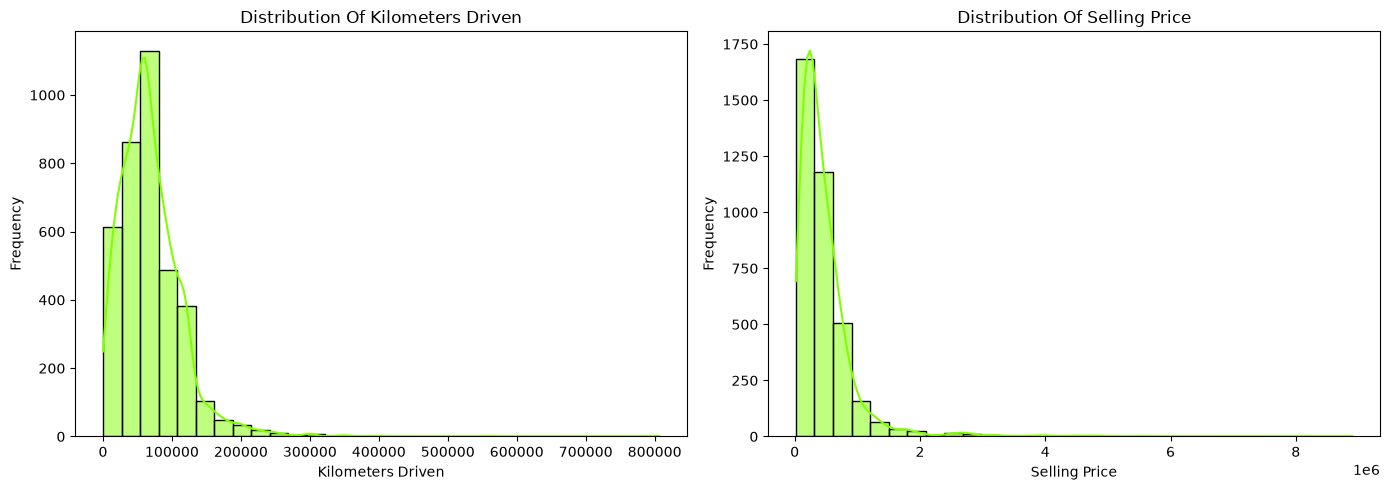

In [86]:
# Data Visuals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# km_driven Histogram
sns.histplot(
    df["km_driven"],
    bins=30,
    kde=True,
    color="#80FF00",
    ax=axes[0],
    edgecolor="black"
)
axes[0].set_title("Distribution Of Kilometers Driven")
axes[0].set_xlabel("Kilometers Driven")
axes[0].set_ylabel("Frequency")

# selling_price Histogram
sns.histplot(
    df["selling_price"],
    bins=30,
    kde=True,
    color="#80FF00",
    ax=axes[1],
    edgecolor="black"
)
axes[1].set_title("Distribution Of Selling Price")
axes[1].set_xlabel("Selling Price")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

